# Breast Ultrasound Classification — BUSI Dataset
### Handling Multi-Class Imbalance | 6 Experiments with ResNet50

In [1]:
!pip install -q kagglehub albumentations imbalanced-learn

In [2]:
import os, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

---
## 1. Load & Split Data

In [4]:
import kagglehub
path = kagglehub.dataset_download("subhajournal/busi-breast-ultrasound-images-dataset")
data_path = os.path.join(path, "Dataset_BUSI_with_GT")

classes = ["benign", "malignant", "normal"]
paths, labels = [], []

for cls in classes:
    for img in os.listdir(os.path.join(data_path, cls)):
        if "_mask" not in img:
            paths.append(os.path.join(data_path, cls, img))
            labels.append(cls)

data = pd.DataFrame({"path": paths, "label": labels})
data["label"] = data["label"].map({"benign":0, "malignant":1, "normal":2})
print(data["label"].value_counts())

Using Colab cache for faster access to the 'busi-breast-ultrasound-images-dataset' dataset.
label
0    437
1    210
2    133
Name: count, dtype: int64


In [5]:
train_df, temp_df = train_test_split(data, test_size=0.30, stratify=data["label"], random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))

Train: 546  Val: 117  Test: 117


---
## 2. Dataset & Transforms

In [6]:
class UltrasoundDS(Dataset):
    def __init__(self, df, tf):
        self.df, self.tf = df, tf
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        img = np.array(Image.open(self.df.iloc[i]["path"]).convert("RGB"), dtype=np.uint8)
        return self.tf(image=img)["image"], int(self.df.iloc[i]["label"])

In [7]:
_n = A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))

basic_tf = A.Compose([A.Resize(224,224), _n, ToTensorV2()])

aug_tf = A.Compose([
    A.Resize(224,224),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussianBlur(p=0.3),
    _n, ToTensorV2()
])

In [8]:
train_ds     = UltrasoundDS(train_df, basic_tf)
train_ds_aug = UltrasoundDS(train_df, aug_tf)
val_ds       = UltrasoundDS(val_df,   basic_tf)
test_ds      = UltrasoundDS(test_df,  basic_tf)

train_loader = DataLoader(train_ds,     batch_size=16, shuffle=True)
train_aug_loader = DataLoader(train_ds_aug, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,  batch_size=16)
test_loader  = DataLoader(test_ds, batch_size=16)

---
## 3. Model, Loss & Helpers

In [9]:
def build_model():
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, 3)
    return m.to(device)

In [10]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
    def forward(self, inp, tgt):
        ce = nn.functional.cross_entropy(inp, tgt, reduction="none")
        return ((1 - torch.exp(-ce)) ** self.gamma * ce).mean()

In [11]:
def get_weighted_loader(ds, df):
    counts = df["label"].value_counts().sort_index()
    w = 1. / torch.tensor(counts.values, dtype=torch.float)
    sw = w[df["label"].values]
    sampler = WeightedRandomSampler(sw, len(sw), replacement=True)
    return DataLoader(ds, batch_size=16, sampler=sampler)

weighted_loader = get_weighted_loader(train_ds_aug, train_df)

---
## 4. Train & Evaluate Functions

In [33]:
def train_model(model, loader, criterion, optimizer, epochs=8):
    for ep in range(epochs):
        model.train()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            criterion(model(x), y).backward()
            optimizer.step()
        print(f"Epoch {ep+1}/{epochs} done")

In [72]:
results = {}

def evaluate_model(model, name):
    model.eval()
    preds, true = [], []
    with torch.no_grad():
        for x, y in test_loader:
            _, p = torch.max(model(x.to(device)), 1)
            preds.extend(p.cpu().numpy())
            true.extend(y.numpy())


    results[name] = {"Accuracy": accuracy_score(true, preds),
                     "F1 Score": f1_score(true, preds, average="macro", zero_division=0),
                     "Precision": precision_score(true, preds, average="macro", zero_division=0),
                     "Recall": recall_score(true, preds, average="macro", zero_division=0)}

    print(f"\n{name}")
    print(classification_report(true, preds, target_names=classes))

    sns.heatmap(confusion_matrix(true, preds), annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(name); plt.show()

---
## 5. Experiments

### Exp 1 — Baseline
No augmentation. CrossEntropy. Shows raw imbalance effect.

In [73]:
m1 = build_model()
train_model(m1, train_loader, nn.CrossEntropyLoss(), optim.Adam(m1.parameters(), lr=1e-4))

Epoch 1/8 done
Epoch 2/8 done
Epoch 3/8 done
Epoch 4/8 done
Epoch 5/8 done
Epoch 6/8 done
Epoch 7/8 done
Epoch 8/8 done



Baseline
              precision    recall  f1-score   support

      benign       0.80      0.85      0.82        66
   malignant       0.78      0.68      0.72        31
      normal       0.80      0.80      0.80        20

    accuracy                           0.79       117
   macro avg       0.79      0.78      0.78       117
weighted avg       0.79      0.79      0.79       117



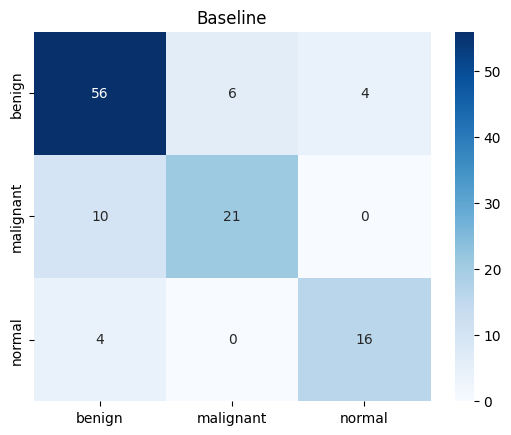

In [76]:
evaluate_model(m1, "Baseline")

### Exp 2 — Augmentation
Flip, rotate, brightness, blur. Same loss, no sampler.

In [54]:
m2 = build_model()
train_model(m2, train_aug_loader, nn.CrossEntropyLoss(), optim.Adam(m2.parameters(), lr=1e-4))

Epoch 1/8 done
Epoch 2/8 done
Epoch 3/8 done
Epoch 4/8 done
Epoch 5/8 done
Epoch 6/8 done
Epoch 7/8 done
Epoch 8/8 done



Augmentation
              precision    recall  f1-score   support

      benign       0.77      0.83      0.80        66
   malignant       0.75      0.58      0.65        31
      normal       0.77      0.85      0.81        20

    accuracy                           0.77       117
   macro avg       0.77      0.75      0.76       117
weighted avg       0.77      0.77      0.76       117



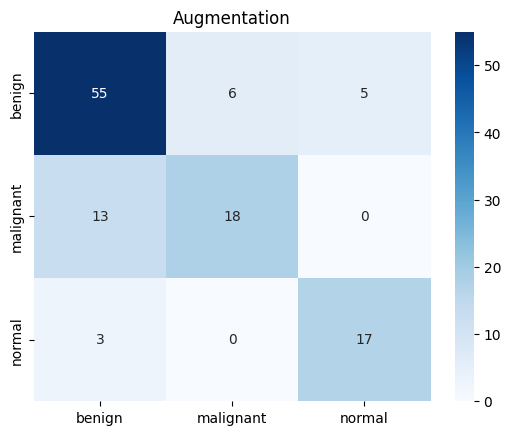

In [78]:
evaluate_model(m2, "Augmentation")

### Exp 3 — Weighted Sampling
Inverse-frequency sampler. Minority classes seen more per batch.

In [56]:
m3 = build_model()
train_model(m3, weighted_loader, nn.CrossEntropyLoss(), optim.Adam(m3.parameters(), lr=1e-4))

Epoch 1/8 done
Epoch 2/8 done
Epoch 3/8 done
Epoch 4/8 done
Epoch 5/8 done
Epoch 6/8 done
Epoch 7/8 done
Epoch 8/8 done



Weighted Sampling
              precision    recall  f1-score   support

      benign       0.82      0.80      0.81        66
   malignant       0.69      0.77      0.73        31
      normal       0.82      0.70      0.76        20

    accuracy                           0.78       117
   macro avg       0.77      0.76      0.76       117
weighted avg       0.78      0.78      0.78       117



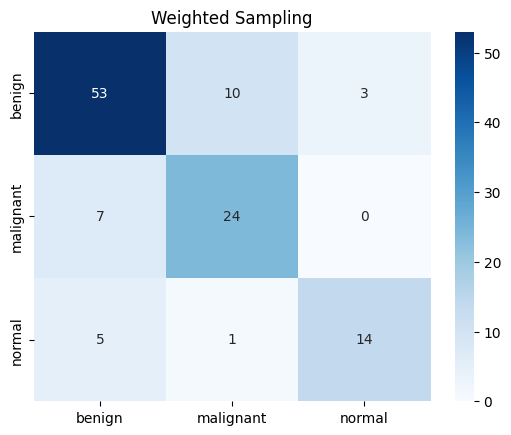

In [79]:
evaluate_model(m3, "Weighted Sampling")

### Exp 4 — Focal Loss
Focal Loss (γ=2) focuses gradient on hard minority examples.

In [58]:
m4 = build_model()
train_model(m4, weighted_loader, FocalLoss(gamma=2), optim.Adam(m4.parameters(), lr=1e-4))

Epoch 1/8 done
Epoch 2/8 done
Epoch 3/8 done
Epoch 4/8 done
Epoch 5/8 done
Epoch 6/8 done
Epoch 7/8 done
Epoch 8/8 done



Focal Loss
              precision    recall  f1-score   support

      benign       0.82      0.77      0.80        66
   malignant       0.73      0.77      0.75        31
      normal       0.73      0.80      0.76        20

    accuracy                           0.78       117
   macro avg       0.76      0.78      0.77       117
weighted avg       0.78      0.78      0.78       117



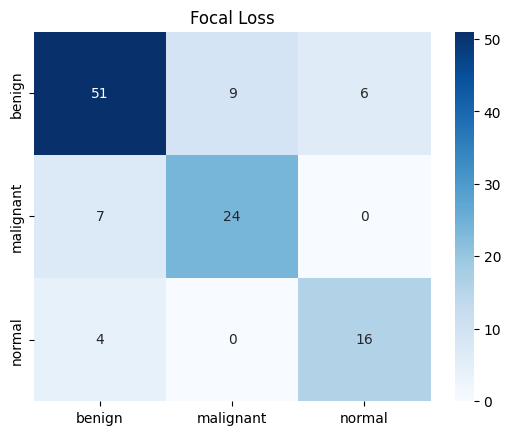

In [75]:
evaluate_model(m4, "Focal Loss")

### Exp 5 — SMOTE Hybrid
ResNet50 extracts features → SMOTE balances → MLP classifies.

In [61]:
def get_feats(df):
    fe = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    fe.fc = nn.Identity()
    fe.to(device).eval()
    ld = DataLoader(UltrasoundDS(df, basic_tf), batch_size=32)
    with torch.no_grad():
        feats = [fe(x.to(device)).cpu().numpy() for x, _ in ld]
    return np.vstack(feats)

In [62]:
Xr, yr = SMOTE(random_state=42).fit_resample(Xtr, ytr)

sc = StandardScaler()
Xr     = sc.fit_transform(Xr)
Xts_sc = sc.transform(Xts)

mlp = MLPClassifier(hidden_layer_sizes=(512, 256), max_iter=300, random_state=42)
mlp.fit(Xr, yr)

MLPClassifier(hidden_layer_sizes=(512, 256), max_iter=300, random_state=42)

              precision    recall  f1-score   support

      benign       0.85      0.80      0.83        66
   malignant       0.67      0.77      0.72        31
      normal       0.74      0.70      0.72        20

    accuracy                           0.78       117
   macro avg       0.75      0.76      0.75       117
weighted avg       0.78      0.78      0.78       117



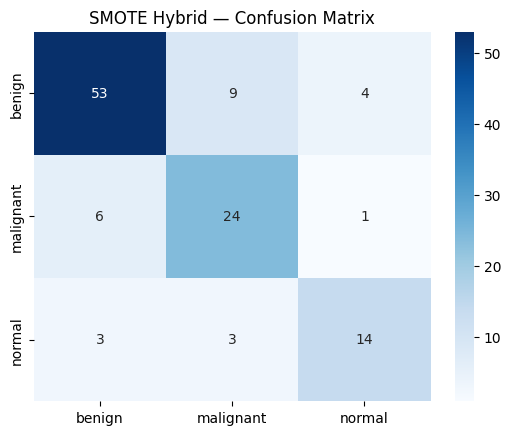

In [80]:
sp = mlp.predict(Xts_sc)

results["SMOTE Hybrid"] = {
    "Accuracy":  accuracy_score(yts, sp),
    "Precision": precision_score(yts, sp, average="macro", zero_division=0),
    "Recall":    recall_score(yts, sp, average="macro", zero_division=0),
    "F1 Score":  f1_score(yts, sp, average="macro", zero_division=0)
}

print(classification_report(yts, sp, target_names=classes))

sns.heatmap(confusion_matrix(yts, sp), annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("SMOTE Hybrid — Confusion Matrix")
plt.show()

### Exp 6 — Mixup
Interpolates image-label pairs (λ ~ Beta(0.4,0.4)). Smooths decision boundaries.

In [64]:
def mixup_loss(model, x, y):
    lam = np.random.beta(0.4, 0.4)
    idx = torch.randperm(x.size(0), device=device)
    xm  = lam*x + (1-lam)*x[idx]
    ys  = lam*nn.functional.one_hot(y,3).float() + (1-lam)*nn.functional.one_hot(y[idx],3).float()
    return -(ys * nn.functional.log_softmax(model(xm),1)).sum(1).mean()

m6  = build_model()
opt6 = optim.Adam(m6.parameters(), lr=1e-4)

for ep in range(8):
    m6.train()
    for x, y in weighted_loader:
        x, y = x.to(device), y.to(device)
        opt6.zero_grad()
        mixup_loss(m6, x, y).backward()
        opt6.step()
    print(f"Epoch {ep+1}/8 done")

Epoch 1/8 done
Epoch 2/8 done
Epoch 3/8 done
Epoch 4/8 done
Epoch 5/8 done
Epoch 6/8 done
Epoch 7/8 done
Epoch 8/8 done



Mixup
              precision    recall  f1-score   support

      benign       0.79      0.73      0.76        66
   malignant       0.63      0.77      0.70        31
      normal       0.78      0.70      0.74        20

    accuracy                           0.74       117
   macro avg       0.73      0.73      0.73       117
weighted avg       0.74      0.74      0.74       117



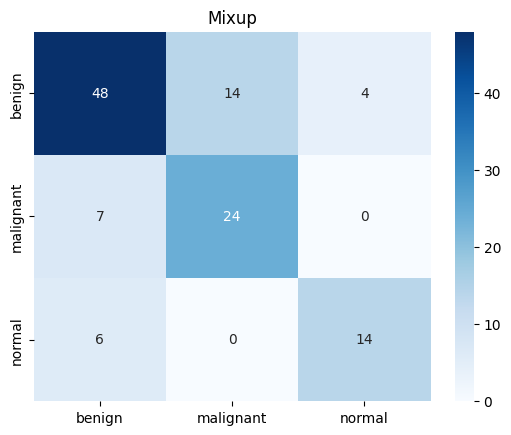

In [81]:
evaluate_model(m6, "Mixup")

---
## 6. Final Comparison

In [82]:
comparison_df = pd.DataFrame(results).T
print("Final Model Comparison")
print(comparison_df.to_string(float_format="{:.4f}".format))

Final Model Comparison
                   Accuracy  F1 Score  Precision  Recall
Focal Loss           0.7778    0.7696     0.7590  0.7823
Baseline             0.7949    0.7826     0.7926  0.7753
Augmentation         0.7692    0.7557     0.7658  0.7547
Weighted Sampling    0.7778    0.7644     0.7749  0.7591
SMOTE Hybrid         0.7778    0.7542     0.7528  0.7591
Mixup                0.7350    0.7295     0.7321  0.7338


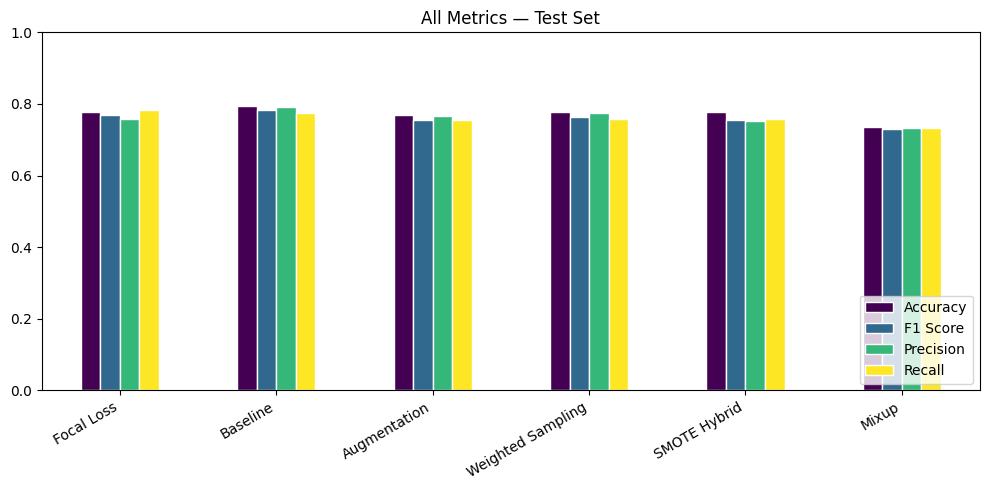

In [83]:
comparison_df.plot(kind="bar", figsize=(10,5), ylim=(0,1),
                   colormap="viridis", edgecolor="white")
plt.title("All Metrics — Test Set")
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()